In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\ML\Downloads\Salary Data (3).csv")

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
df.shape

(375, 6)

In [6]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [7]:
df.select_dtypes(include="object").columns

df.select_dtypes(exclude="object").columns

C:\Users\ML\AppData\Local\Temp\ipykernel_3996\2983632277.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['Age', 'Years of Experience', 'Salary'], dtype='str')

In [8]:
df["Age"].mean()

df["Age"].median()

df["Age"].std()

np.float64(7.069072938567494)

In [9]:
df["Gender"].value_counts(normalize=True)*100

Gender
Male      52.010724
Female    47.989276
Name: proportion, dtype: float64

In [10]:
df["Education Level"].value_counts(normalize=True)*100

Education Level
Bachelor's    60.053619
Master's      26.273458
PhD           13.672922
Name: proportion, dtype: float64

In [11]:
df[df.isnull().all(axis=1)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.duplicated().sum()

np.int64(50)

In [13]:
df = df.dropna(how="all")

df = df.drop_duplicates()

df = df.reset_index(drop=True)

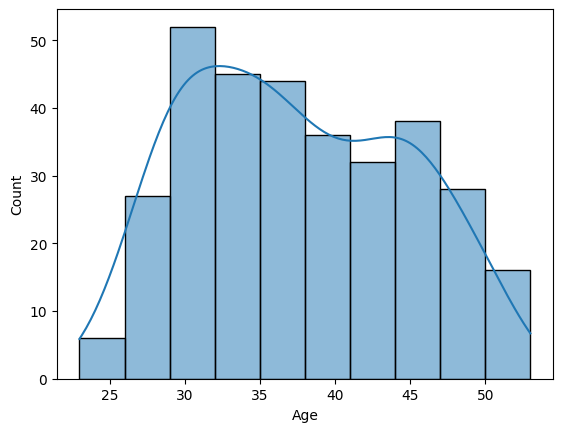

In [14]:
import seaborn as sns
sns.histplot(df['Age'], kde=True)

plt.show()

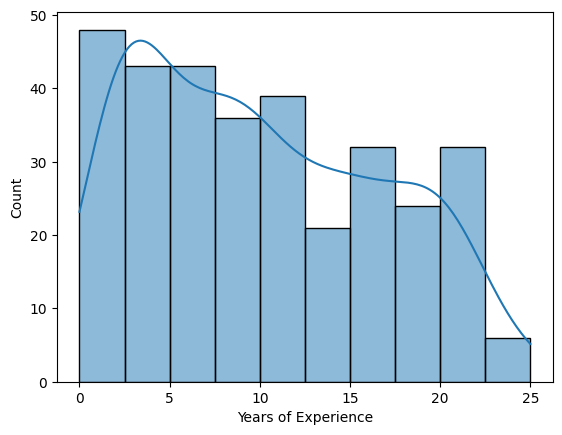

In [23]:
sns.histplot(df['Years of Experience'], kde=True)

plt.show()

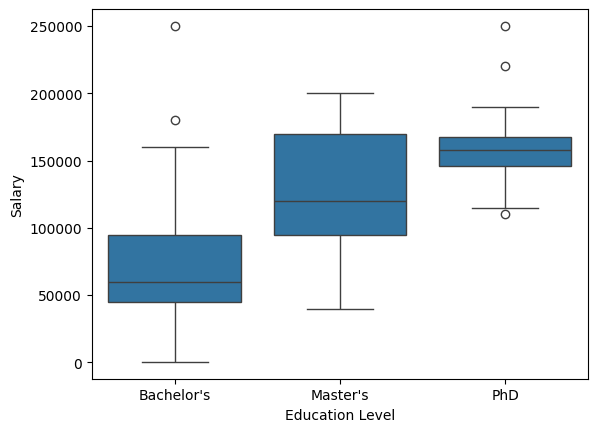

In [24]:
sns.boxplot(x="Education Level",
            y="Salary",
            data=df)

plt.show()

In [17]:
df.groupby("Gender")["Salary"].mean()

Gender
Female     96136.363636
Male      103472.647059
Name: Salary, dtype: float64

In [18]:
df.groupby("Education Level")["Salary"].mean()

Education Level
Bachelor's     73902.356021
Master's      127912.087912
PhD           158095.238095
Name: Salary, dtype: float64

In [19]:
bins = [0,5,10,15,20,100]

labels = ["0-5","6-10","11-15","16-20","20+"]

df["Exp_Category"] = pd.cut(
    df["Years of Experience"],
    bins=bins,
    labels=labels
)

df.groupby("Exp_Category")["Salary"].mean()

Exp_Category
0-5       49330.288462
6-10      92215.189873
11-15    115178.571429
16-20    158684.210526
20+      175400.000000
Name: Salary, dtype: float64

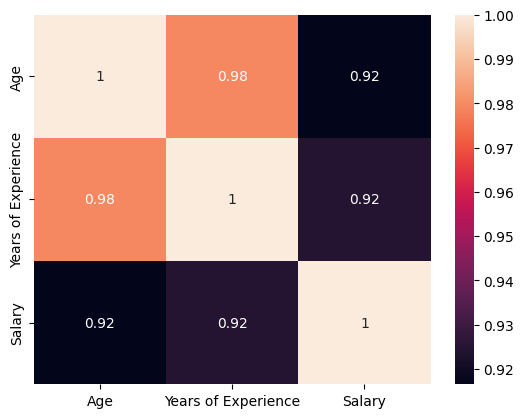

In [20]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True)

plt.show()

In [25]:
df_clean=df.dropna()
df_clean=df_clean.reset_index(drop=True)

In [26]:
df_encoded=pd.get_dummies(df_clean, drop_first=True)
df_encoded

,Age,Years of Experience,Salary,Gender_Male,Education Level_Master's,Education Level_PhD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Business Analyst,Job Title_Business Development Manager,...,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer,Exp_Category_6-10,Exp_Category_11-15,Exp_Category_16-20,Exp_Category_20+
0,32.0,5.0,90000.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,28.0,3.0,65000.0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,45.0,15.0,150000.0,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,36.0,7.0,60000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,52.0,20.0,200000.0,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,28.0,1.0,35000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
317,36.0,8.0,110000.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
318,44.0,16.0,160000.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
319,31.0,3.0,55000.0,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [29]:
X = df_encoded.drop("Salary", axis=1)

y = df_encoded["Salary"]
print(X.columns)
print(y.name)

Index(['Age', 'Years of Experience', 'Gender_Male', 'Education Level_Master's',
       'Education Level_PhD', 'Job Title_Accountant',
       'Job Title_Administrative Assistant', 'Job Title_Business Analyst',
       'Job Title_Business Development Manager',
       'Job Title_Business Intelligence Analyst',
       ...
       'Job Title_Training Specialist', 'Job Title_UX Designer',
       'Job Title_UX Researcher', 'Job Title_VP of Finance',
       'Job Title_VP of Operations', 'Job Title_Web Developer',
       'Exp_Category_6-10', 'Exp_Category_11-15', 'Exp_Category_16-20',
       'Exp_Category_20+'],
      dtype='str', length=179)
Salary


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.8443284130619417

In [34]:
from sklearn.metrics import mean_squared_error

np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(18323.167779522082)

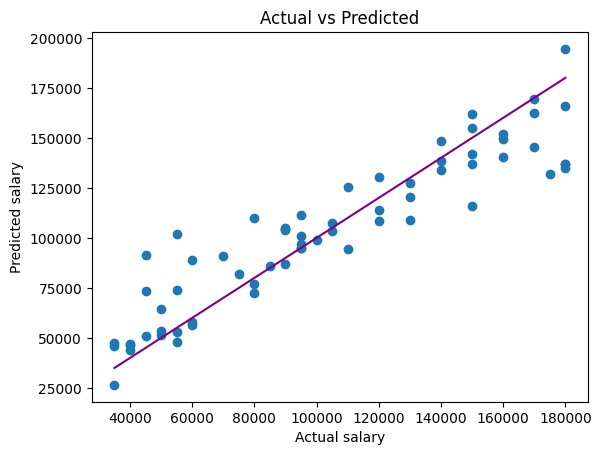

In [36]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual salary")
plt.ylabel('Predicted salary')
plt.title('Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='purple')

plt.show()